In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# para as figuras não ficarem tão grandes
plt.rcParams['figure.figsize'] = (4, 3)

# CORRELATIONS

In [ ]:
# https://dontpad.com/bcc-ds-02

df = pd.read_csv('https://raysonlaroca.github.io/' +
                 'teaching/data-science/datasets/meses_producao_custo.csv')

In [ ]:
df

,Meses,litros,custo
0,Jan,20200,19000
1,Fev,16700,17000
2,Mar,14800,14000
3,Abr,16000,15000
4,Mai,12100,14000
5,Jun,13000,15000
6,Jul,11600,13000
7,Ago,15500,16000
8,Set,18900,18000
9,Out,20000,19000


<Axes: xlabel='litros', ylabel='custo'>

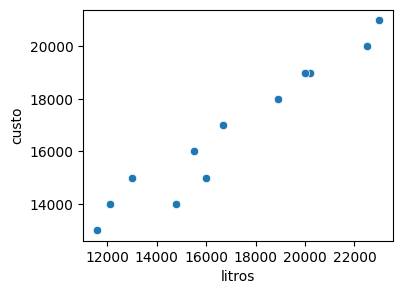

In [ ]:
sns.scatterplot(data=df, x='litros', y='custo')

<Axes: xlabel='litros', ylabel='custo'>

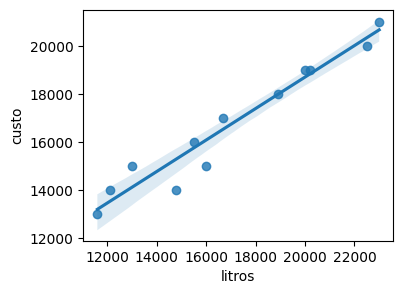

In [ ]:
# gráfico de dispersão com linha de regressão
sns.regplot(data=df, x='litros', y='custo')

<Axes: xlabel='litros', ylabel='custo'>

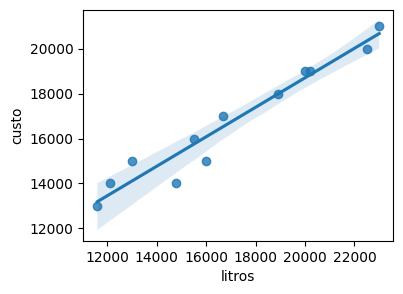

In [ ]:
# intervalo de confiança de 99% ao redor da linha de regressão
sns.regplot(data=df, x='litros', y='custo', ci=99)

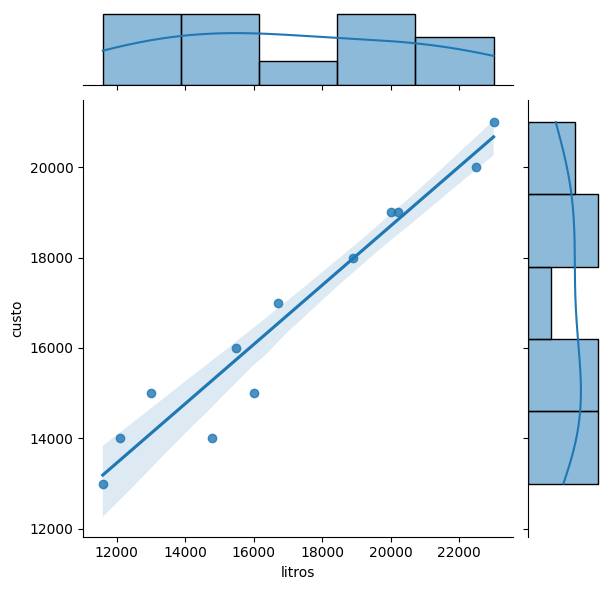

In [ ]:
sns.jointplot(data=df, x='litros', y='custo', kind='reg')

# reparem, temos uma análise univariada e multivariada
# ao mesmo tempo

In [ ]:
# A função stats.pearsonr() retorna dois valores:
# r: coeficiente de correlação
# _: p-valor associado ao teste estatístico (próximas aulas)
r, _ = stats.pearsonr(df['litros'], df['custo'])

# Exibe o valor da correlação
r

np.float64(0.9699933926497077)

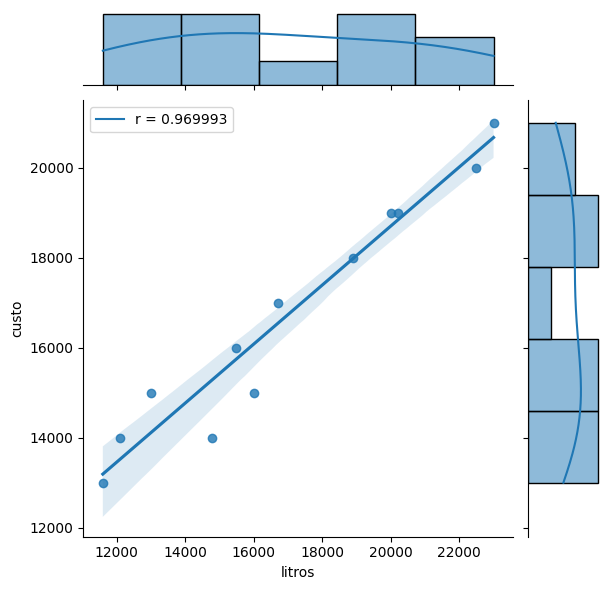

In [ ]:
p = sns.jointplot(data=df, x='litros', y='custo', kind='reg')

# Cria um elemento invisível apenas para permitir a inclusão
# do coeficiente de correlação na legenda
phantom, = p.ax_joint.plot([], [], linestyle='-')

# Adiciona a legenda com o valor de r no gráfico principal
p.ax_joint.legend([phantom], [f'r = {r:.6f}'])

In [ ]:
# usando pandas (em vez de scipy)
r = df['litros'].corr(df['custo'])
r

np.float64(0.9699933926497077)

In [ ]:
df.corr() # Erro -> colunas não numéricas

ValueError: could not convert string to float: 'Jan'

In [ ]:
# Seleciona apenas as colunas numéricas do DataFrame
# e calcula a matriz de correlação entre elas
df.select_dtypes(include=['number']).corr()

,litros,custo
litros,1.000000,0.969993
custo,0.969993,1.000000


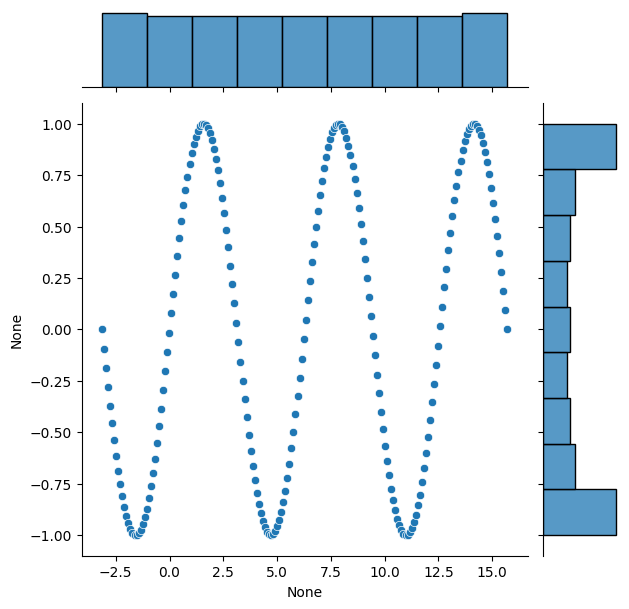

In [ ]:
# Gera 200 valores entre -π e 5π
x = np.linspace(-np.pi, 5*np.pi, 200)

# y é o seno de x
y = np.sin(x)

sns.jointplot(x=x, y=y)

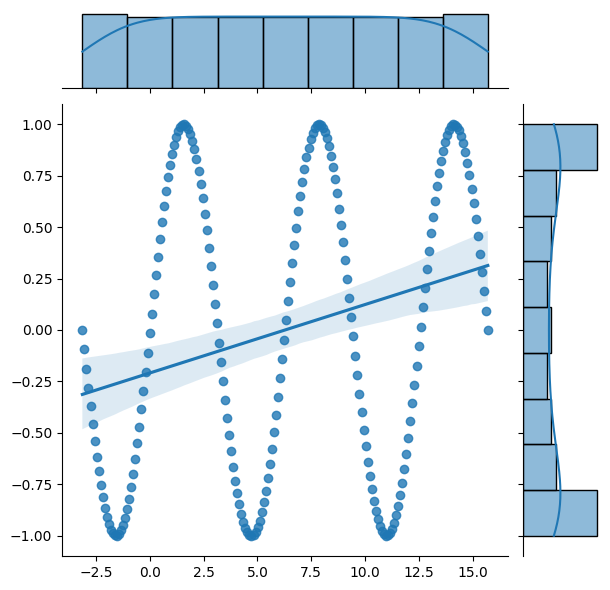

In [ ]:
sns.jointplot(x=x, y=y, kind='reg')

In [ ]:
r, _ = stats.pearsonr(x, y)
r

# A correlação foi baixa (0.26)
# mesmo com y sendo totalmente determinado por x

np.float64(0.25776245829087957)

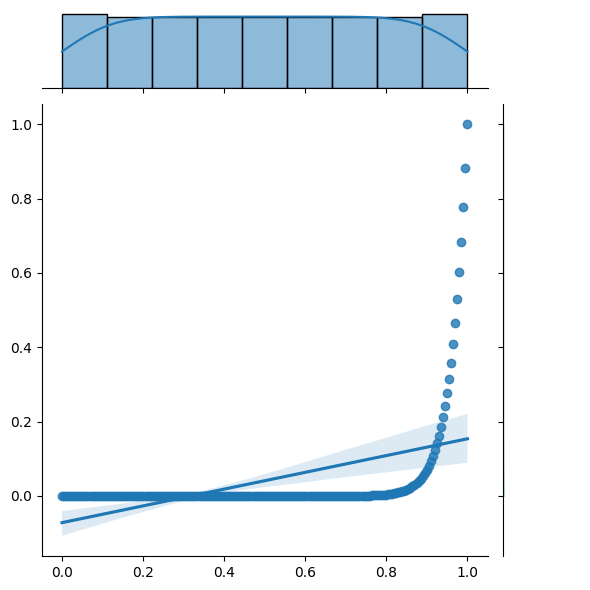

In [ ]:
# Outro exemplo

# Gera valores de x entre 0 e 1
x = np.linspace(0, 1, 200)

# Relação monotônica: quando x aumenta, y nunca diminui
# Aqui, y cresce sempre, mas de forma não linear
y = x**25

# Visualiza a relação entre x e y
sns.jointplot(x=x, y=y, kind='reg')

In [ ]:
pearson, _ = stats.pearsonr(x, y)
spearman, _ = stats.spearmanr(x, y)

print(f'Pearson: {pearson:.4f}')
print(f'Spearman: {spearman:.4f}')

Pearson: 0.4579
Spearman: 1.0000


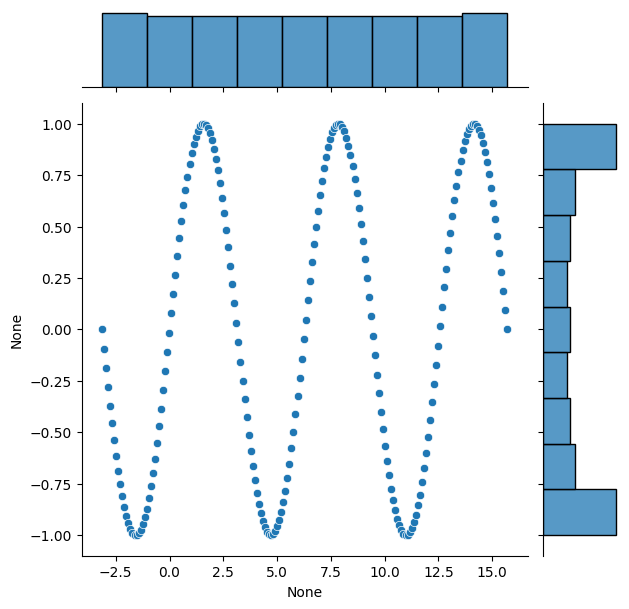

In [ ]:
# Repetindo o experimento anterior (senoidal)

# Gera 200 valores entre -π e 5π
x = np.linspace(-np.pi, 5*np.pi, 200)

# y é o seno de x
y = np.sin(x)

sns.jointplot(x=x, y=y)

In [ ]:
pearson, _ = stats.pearsonr(x, y)
spearman, _ = stats.spearmanr(x, y)

print(f'Pearson: {pearson:.4f}')
print(f'Spearman: {spearman:.4f}')

# Pearson: 0.2578
# Spearman: 0.2487

# As duas correlações ficam baixas porque a relação não é linear
# e também não é monotônica no intervalo analisado

# O seno sobe e desce várias vezes
# então, à medida que x aumenta, y às vezes aumenta e às vezes diminui

# Por isso:
# Pearson é baixo, pois não há uma tendência linear clara
# Spearman também é baixo, pois a ordem dos valores não é preservada

Pearson: 0.2578
Spearman: 0.2487


# RELATION BETWEEN CATEGORICAL VARIABLES

In [ ]:
# https://dontpad.com/bcc-ds-02

df = pd.read_csv('https://raysonlaroca.github.io/'
    + 'teaching/data-science/datasets/titanic.csv')

In [ ]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [ ]:
# há relação entre sexo e sobrevivência?

# tabela de contingência
ctab = pd.crosstab(df['Sex'], df['Survived'])
ctab

Survived,0,1
Sex,,
female,81,233
male,468,109


In [ ]:
df_adultos = df[df['Age'] >= 15]

ctab = pd.crosstab(df_adultos['Sex'], df_adultos['Survived'])
ctab

Survived,0,1
Sex,,
female,49,173
male,342,72


<Axes: xlabel='Survived', ylabel='Sex'>

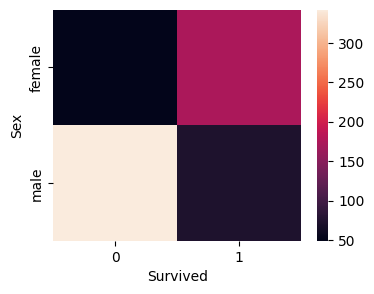

In [ ]:
sns.heatmap(ctab) # piorou?!

<Axes: xlabel='Survived', ylabel='Sex'>

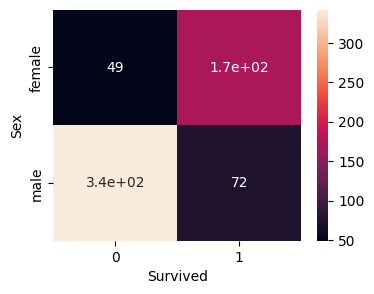

In [ ]:
sns.heatmap(ctab, annot=True) # melhorou, mas não muito...

<Axes: xlabel='Survived', ylabel='Sex'>

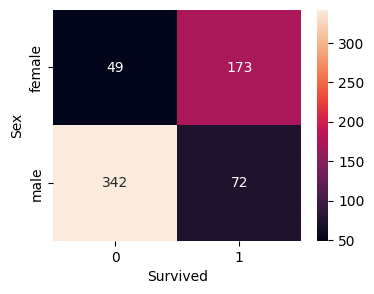

In [ ]:
sns.heatmap(ctab, annot=True,
            fmt='d') # melhorou legal

<Axes: xlabel='Survived', ylabel='Sex'>

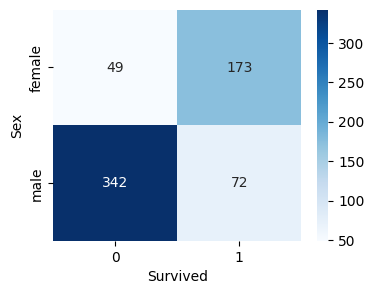

In [ ]:
sns.heatmap(ctab, annot=True,
            fmt='d', cmap='Blues') # nice

<Axes: xlabel='Survived', ylabel='Sex'>

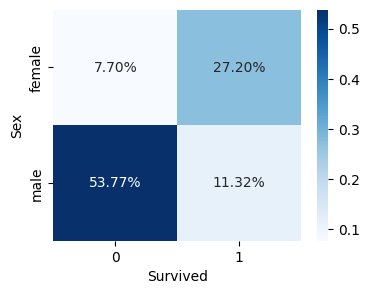

In [ ]:
# # proporções (parâmetro normalize)
ctab_norm = pd.crosstab(df_adultos['Sex'],
                        df_adultos['Survived'],
                        normalize='all')
sns.heatmap(ctab_norm, annot=True,
            fmt='.2%', cmap='Blues')

<Axes: xlabel='Survived', ylabel='Sex'>

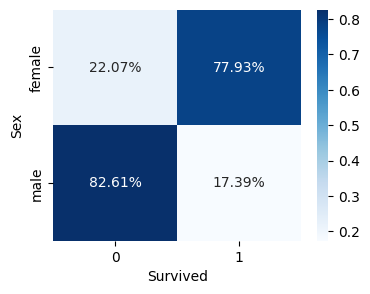

In [ ]:
# proporções por linha
ctab_norm = pd.crosstab(df_adultos['Sex'],
                        df_adultos['Survived'],
                        normalize='index') # antes era 'all'
sns.heatmap(ctab_norm, annot=True,
            fmt='.2%', cmap='Blues')

<Axes: xlabel='Survived', ylabel='Sex'>

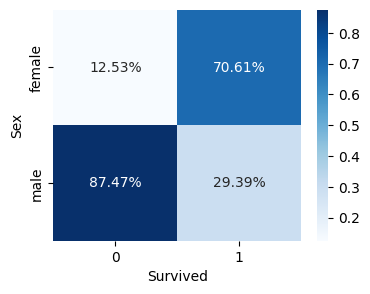

In [ ]:
# proporções por coluna
ctab_norm = pd.crosstab(df_adultos['Sex'],
                        df_adultos['Survived'],
                        normalize='columns')
sns.heatmap(ctab_norm, annot=True,
            fmt='.2%', cmap='Blues')

In [ ]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


<Axes: xlabel='Survived', ylabel='Pclass'>

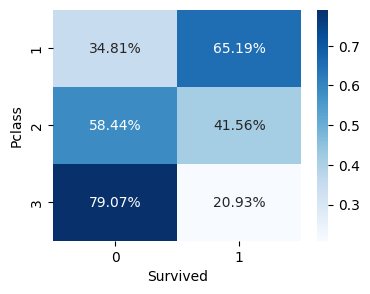

In [ ]:
# há relação entre classe e sobrevivência?

ctab_norm = pd.crosstab(df_adultos['Pclass'],
                        df_adultos['Survived'],
                        normalize='index')
sns.heatmap(ctab_norm, annot=True,
            fmt='.2%', cmap='Blues')

<Axes: xlabel='Survived', ylabel='Pclass'>

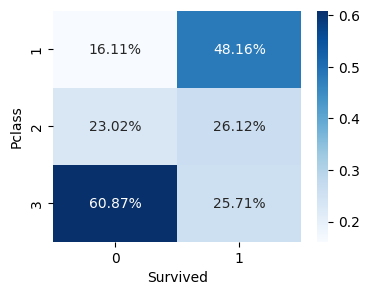

In [ ]:
ctab_norm = pd.crosstab(df_adultos['Pclass'],
                        df_adultos['Survived'],
                        normalize='columns')
sns.heatmap(ctab_norm, annot=True,
            fmt='.2%', cmap='Blues')

<Axes: xlabel='Survived', ylabel='Sex-Pclass'>

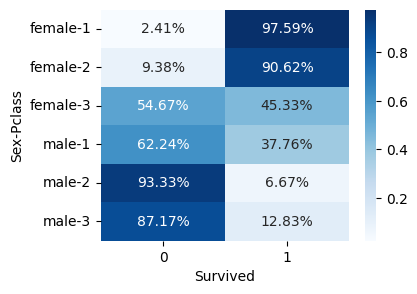

In [ ]:
# 3 variáveis
ctab_norm = pd.crosstab([df_adultos['Sex'],
                        df_adultos['Pclass']],
                        df_adultos['Survived'],
                        normalize='index')
sns.heatmap(ctab_norm, annot=True,
            fmt='.2%', cmap='Blues')

# MULTICOLLINEARITY


In [ ]:
# https://dontpad.com/bcc-ds-02

df = pd.read_csv('https://raysonlaroca.github.io/'
+ 'teaching/data-science/datasets/ommlbd_familiar.csv')

In [ ]:
df.head()

,HS_CPF,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
0,23325,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999
1,667198,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999
2,116666,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999
3,129342,2,1000,1200,2200,1100,54,29,41,0,0,0,0,0,0,0,0,0
4,681531,5,400,1400,4400,880,43,16,25,1,0,0,0,0,0,0,1,1


In [ ]:
df.drop('HS_CPF', axis=1, inplace=True)

In [ ]:
df.head(2)

,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
0,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999
1,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999


In [ ]:
# Calcula a matriz de correlação

corr = df.corr()
corr

,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
QTDPESSOASCASA,1.000000,0.987037,0.892697,0.863329,0.959613,0.999766,0.999766,0.999766,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
MENORRENDACASA,0.987037,1.000000,0.906628,0.887196,0.974987,0.986842,0.986872,0.986864,0.987041,0.987041,0.987041,0.987041,0.987041,0.987041,0.987041,0.987039,0.987042
MAIORRENDACASA,0.892697,0.906628,1.000000,0.980658,0.972949,0.892765,0.892683,0.892729,0.892693,0.892694,0.892693,0.892693,0.892693,0.892693,0.892693,0.892688,0.892698
SOMARENDACASA,0.863329,0.887196,0.980658,1.000000,0.953395,0.863486,0.863336,0.863405,0.863309,0.863310,0.863309,0.863309,0.863310,0.863309,0.863309,0.863304,0.863315
MEDIARENDACASA,0.959613,0.974987,0.972949,0.953395,1.000000,0.959548,0.959540,0.959555,0.959616,0.959617,0.959617,0.959617,0.959617,0.959617,0.959617,0.959613,0.959620
MAIORIDADECASA,0.999766,0.986842,0.892765,0.863486,0.959548,1.000000,0.999999,1.000000,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766
MENORIDADECASA,0.999766,0.986872,0.892683,0.863336,0.959540,0.999999,1.000000,1.000000,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766
MEDIAIDADECASA,0.999766,0.986864,0.892729,0.863405,0.959555,1.000000,1.000000,1.000000,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766,0.999766
INDICMENORDEIDADE,1.000000,0.987041,0.892693,0.863309,0.959616,0.999766,0.999766,0.999766,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
COBRANCABAIXOCASA,1.000000,0.987041,0.892694,0.863310,0.959617,0.999766,0.999766,0.999766,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


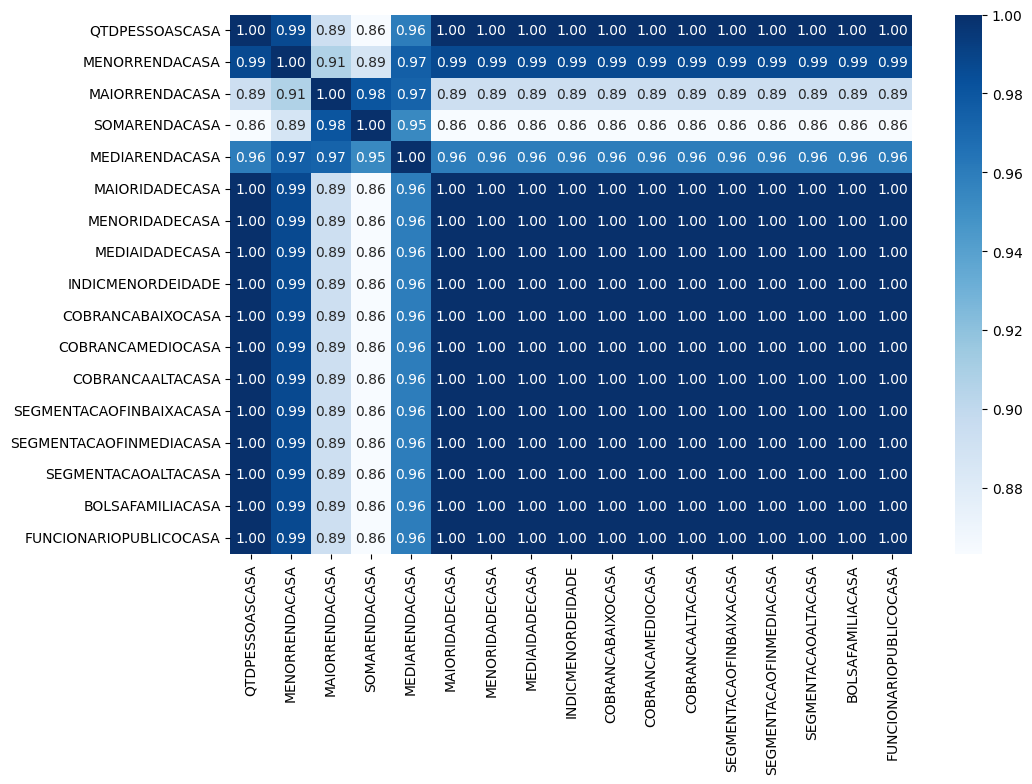

In [ ]:
fig = plt.figure(figsize=(11, 7))
sns.heatmap(corr, annot=True,
            fmt='.2f', cmap='Blues')
plt.show()

# Estranho: valores muito altos de correlação!

In [ ]:
# Precisamos remover os valores -9999
df.replace(-9999, np.nan, inplace=True)
corr = df.corr()

In [ ]:
df.head(2)

,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


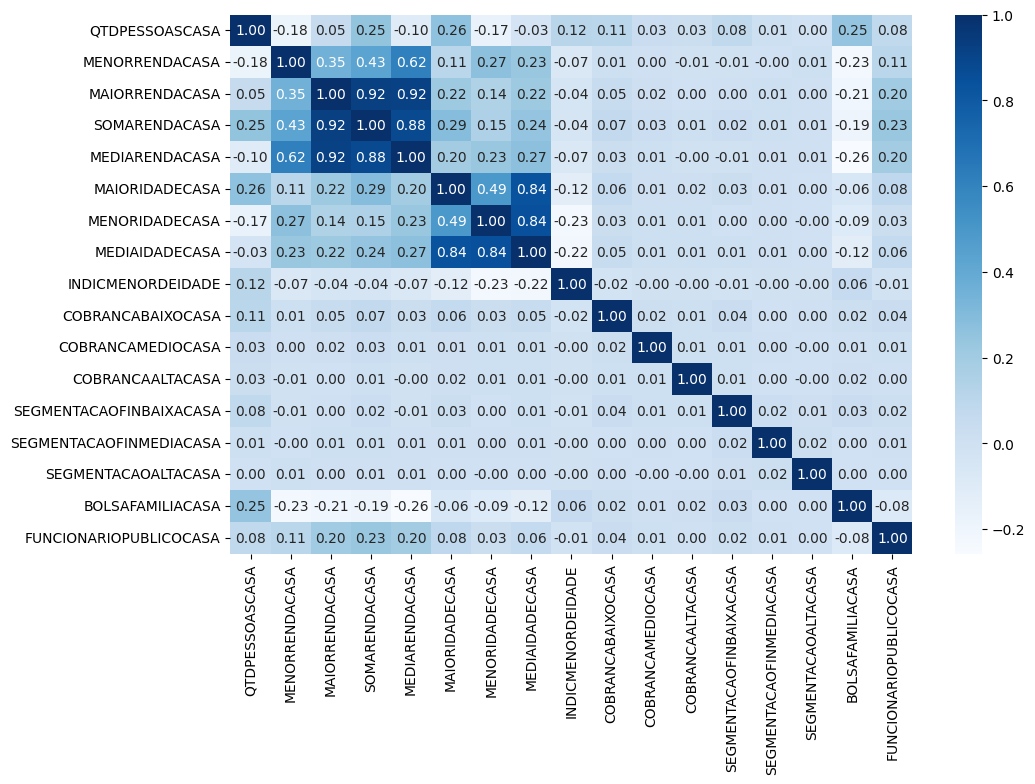

In [ ]:
fig = plt.figure(figsize=(11, 7))
sns.heatmap(corr, annot=True,
            fmt='.2f', cmap='Blues')
plt.show()

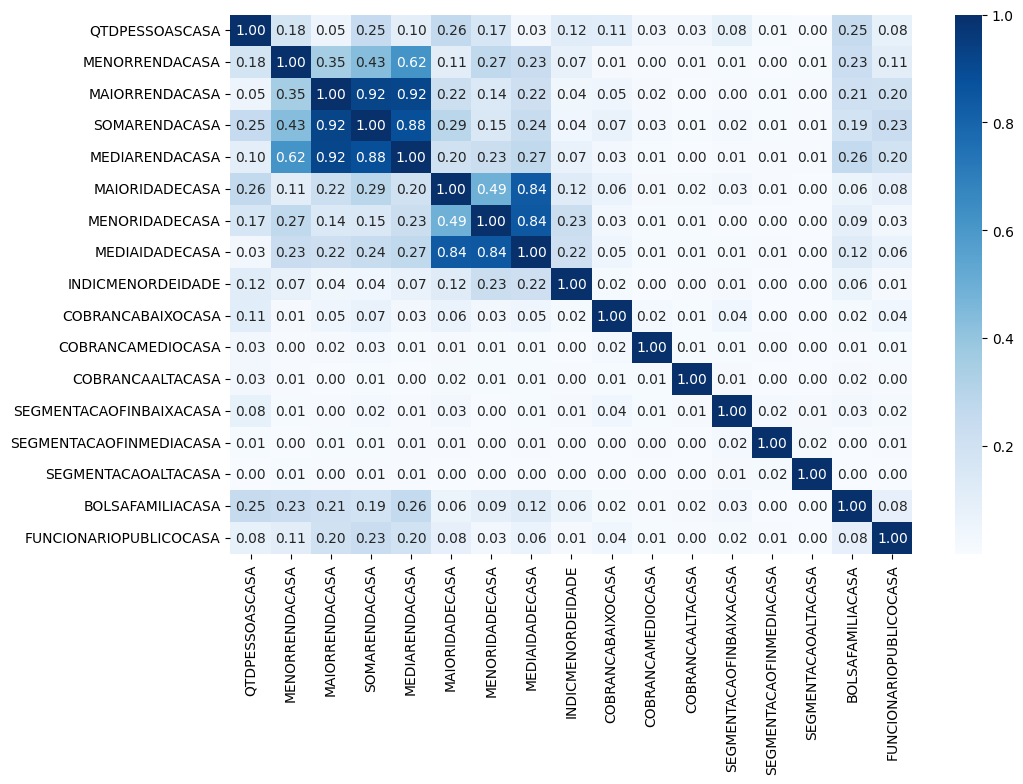

In [ ]:
corr = abs(df.corr()) # valores absolutos
fig = plt.figure(figsize=(11, 7))
sns.heatmap(corr, annot=True,
            fmt='.2f', cmap='Blues')
plt.show()

##  Variable Inflation Factor (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df.head(2)

,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Substitui valores faltantes por 0
# Necessário para calcular o VIF (não aceita NaN)

df.fillna(0.0, inplace=True)

In [ ]:
df.head(2)

,QTDPESSOASCASA,MENORRENDACASA,MAIORRENDACASA,SOMARENDACASA,MEDIARENDACASA,MAIORIDADECASA,MENORIDADECASA,MEDIAIDADECASA,INDICMENORDEIDADE,COBRANCABAIXOCASA,COBRANCAMEDIOCASA,COBRANCAALTACASA,SEGMENTACAOFINBAIXACASA,SEGMENTACAOFINMEDIACASA,SEGMENTACAOALTACASA,BOLSAFAMILIACASA,FUNCIONARIOPUBLICOCASA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# função
def calcula_vif(X):
    # cria um DataFrame vazio
    vif = pd.DataFrame()

    # adiciona a coluna com o nome
    # das variáveis
    vif['variaveis'] = X.columns

    # calcula o VIF para cada variável
    # e armazena no dataframe
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif

In [ ]:
resultado_vif = calcula_vif(df) # 30 seg?

In [ ]:
resultado_vif

,variaveis,VIF
0,QTDPESSOASCASA,13.109708
1,MENORRENDACASA,5.410426
2,MAIORRENDACASA,31.639622
3,SOMARENDACASA,22.037075
4,MEDIARENDACASA,37.092763
5,MAIORIDADECASA,146.077395
6,MENORIDADECASA,50.729167
7,MEDIAIDADECASA,275.968348
8,INDICMENORDEIDADE,1.127165
9,COBRANCABAIXOCASA,1.082300


In [ ]:
resultado_vif.sort_values('VIF', ascending=False)

,variaveis,VIF
7,MEDIAIDADECASA,275.968348
5,MAIORIDADECASA,146.077395
6,MENORIDADECASA,50.729167
4,MEDIARENDACASA,37.092763
2,MAIORRENDACASA,31.639622
3,SOMARENDACASA,22.037075
0,QTDPESSOASCASA,13.109708
1,MENORRENDACASA,5.410426
15,BOLSAFAMILIACASA,1.481190
16,FUNCIONARIOPUBLICOCASA,1.319414


In [ ]:
# Atenção:
    # não remover mais de uma coluna por vez!
    # aqui vamos adotar um limitar de VIF > 10

df.drop('MEDIAIDADECASA', axis=1, inplace=True)

In [ ]:
resultado_vif = calcula_vif(df) # 30 seg?
resultado_vif.sort_values('VIF', ascending=False)

,variaveis,VIF
4,MEDIARENDACASA,36.942244
2,MAIORRENDACASA,31.561195
3,SOMARENDACASA,22.031274
5,MAIORIDADECASA,19.489734
0,QTDPESSOASCASA,12.108425
6,MENORIDADECASA,9.446963
1,MENORRENDACASA,5.403004
14,BOLSAFAMILIACASA,1.479161
15,FUNCIONARIOPUBLICOCASA,1.319413
7,INDICMENORDEIDADE,1.125788


In [ ]:
df.drop('MEDIARENDACASA', axis=1, inplace=True)

resultado_vif = calcula_vif(df) # 30 seg?
resultado_vif.sort_values('VIF', ascending=False)

,variaveis,VIF
3,SOMARENDACASA,21.343831
4,MAIORIDADECASA,19.090174
2,MAIORRENDACASA,15.542359
0,QTDPESSOASCASA,10.809366
5,MENORIDADECASA,9.354114
1,MENORRENDACASA,2.533849
13,BOLSAFAMILIACASA,1.472321
14,FUNCIONARIOPUBLICOCASA,1.318851
6,INDICMENORDEIDADE,1.124348
7,COBRANCABAIXOCASA,1.082166


In [ ]:
df.drop('SOMARENDACASA', axis=1, inplace=True)

resultado_vif = calcula_vif(df) # 30 seg?
resultado_vif.sort_values('VIF', ascending=False)

,variaveis,VIF
3,MAIORIDADECASA,18.561279
4,MENORIDADECASA,9.291664
0,QTDPESSOASCASA,8.117332
2,MAIORRENDACASA,2.191996
1,MENORRENDACASA,2.124135
12,BOLSAFAMILIACASA,1.445123
13,FUNCIONARIOPUBLICOCASA,1.313751
5,INDICMENORDEIDADE,1.112979
6,COBRANCABAIXOCASA,1.081074
9,SEGMENTACAOFINBAIXACASA,1.077154


In [ ]:
df.drop('MAIORIDADECASA', axis=1, inplace=True)

resultado_vif = calcula_vif(df) # 30 seg?
resultado_vif.sort_values('VIF', ascending=False)

,variaveis,VIF
0,QTDPESSOASCASA,4.293272
3,MENORIDADECASA,4.118739
2,MAIORRENDACASA,2.154981
1,MENORRENDACASA,2.120905
11,BOLSAFAMILIACASA,1.440143
12,FUNCIONARIOPUBLICOCASA,1.312773
4,INDICMENORDEIDADE,1.112117
5,COBRANCABAIXOCASA,1.080829
8,SEGMENTACAOFINBAIXACASA,1.077121
6,COBRANCAMEDIOCASA,1.007253


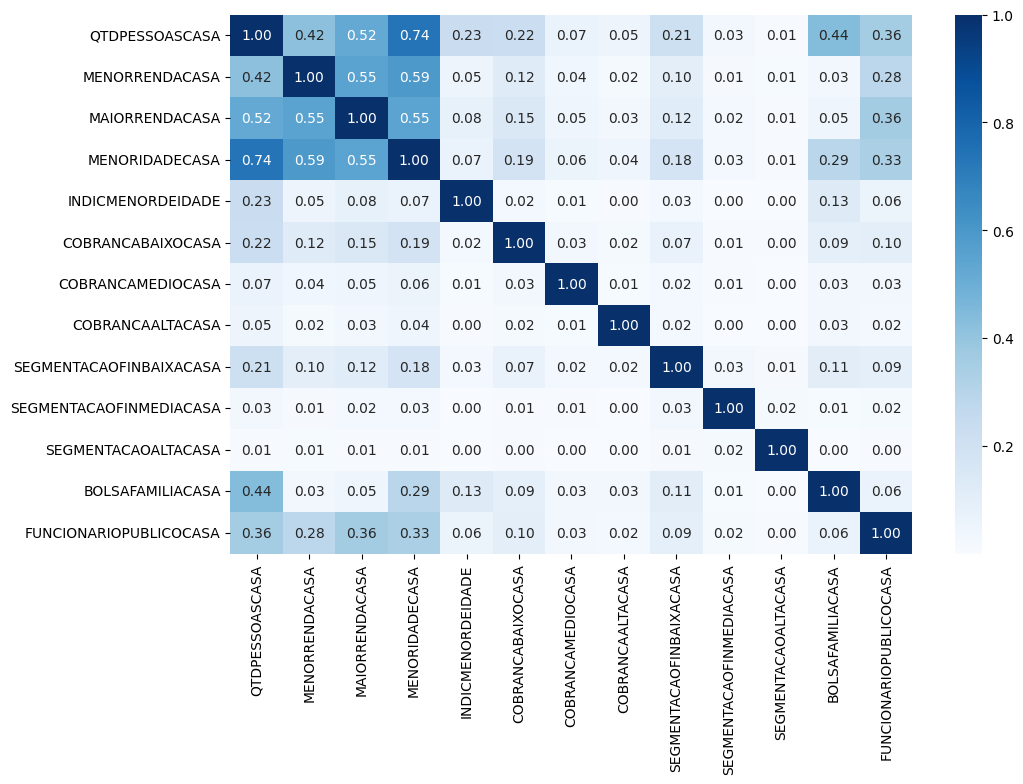

In [ ]:
# mostrar mapa de calor, após a remoção de colunas com VIF alto
corr = abs(df.corr())
fig = plt.figure(figsize=(11, 7))
sns.heatmap(corr, annot=True,
            fmt='.2f', cmap='Blues')
plt.show()